$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
$$

INSERT_setup_intro

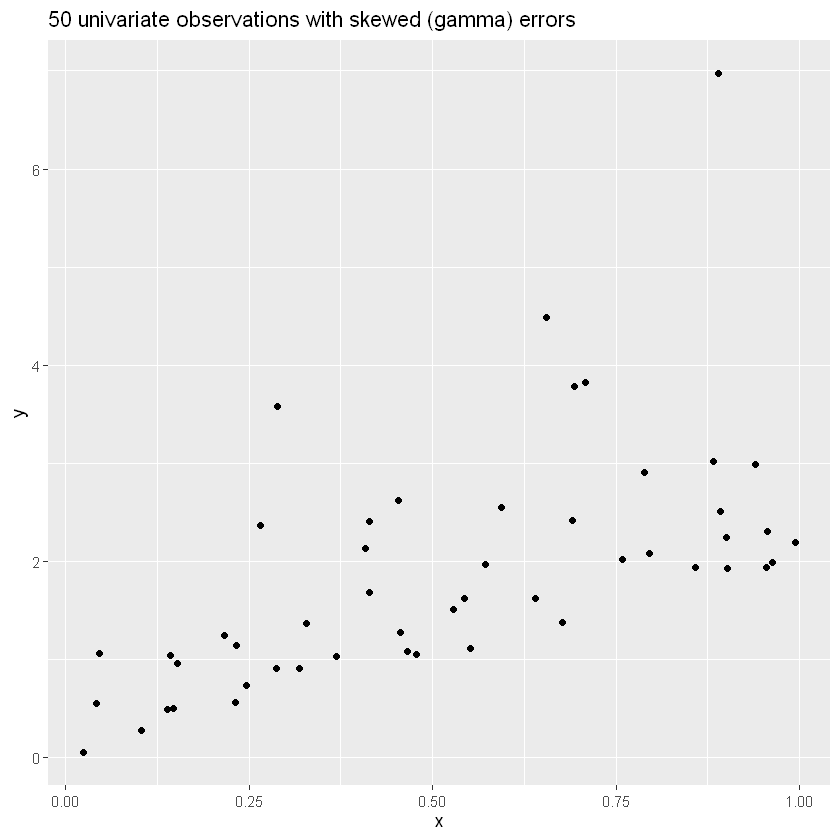

In [1]:
#| label: setup_data
library(ggplot2)

set.seed(123)
n <- 50
x <- runif(n)
y <- 2 * x + rgamma(n, shape = 1)

ggplot(data.frame(x = x, y = y), aes(x, y)) + geom_point() +
  ggtitle("50 univariate observations with skewed (gamma) errors")

INSERT_seeds_note

INSERT_problem_a

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

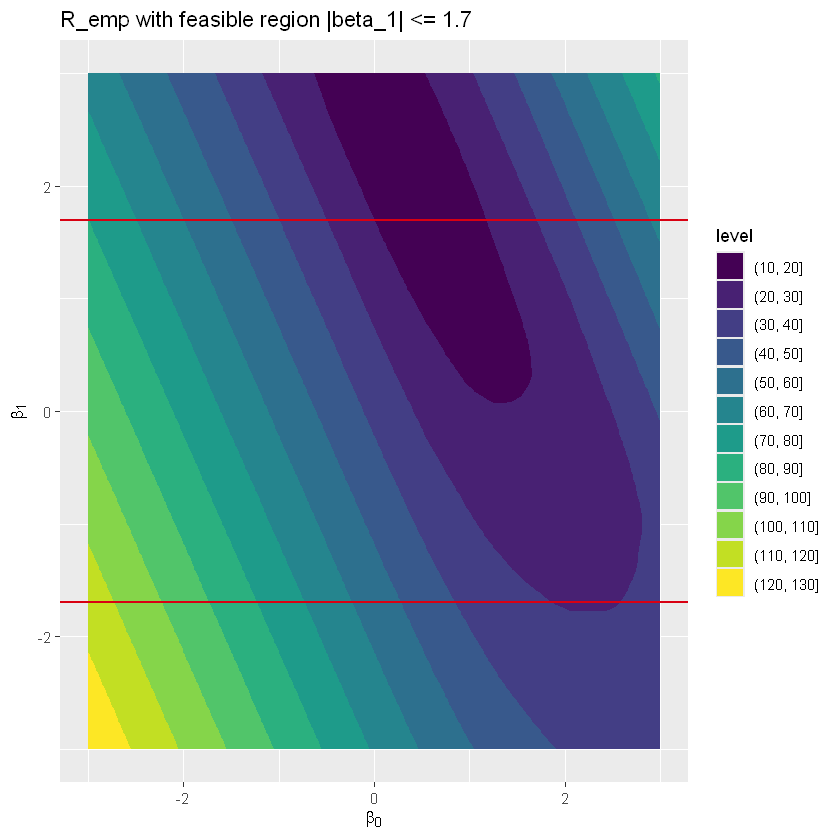

In [2]:
#| label: solution_b_code
tau <- 0.4
tval <- 1.7

# Pinball loss
remp <- function(beta) {
  r <- y - beta[1] - beta[2] * x
  sum(ifelse(r > 0, tau * r, -(1 - tau) * r))
}

b_grid <- seq(-3, 3, by = 0.05)
bb <- expand.grid(X1 = b_grid, X2 = b_grid)
fbb <- apply(bb, 1, remp)
df_grid <- data.frame(bb, fbb = fbb)

remp_plot <- ggplot(df_grid, aes(X1, X2, z = fbb)) +
  geom_contour_filled() +
  geom_hline(yintercept = c(-tval, tval), color = "#D90012", linewidth = 0.7) +
  xlab(expression(beta[0])) + ylab(expression(beta[1])) +
  ggtitle("R_emp with feasible region |beta_1| <= 1.7")
remp_plot

INSERT_solution_b_text

INSERT_problem_c

Warning message:
"package 'linprog' was built under R version 4.4.3"


Loading required package: lpSolve



Warning message:
"package 'lpSolve' was built under R version 4.4.2"


beta_hat = (+0.5062, +1.7000), R_emp* = 13.7880


budget constraint |beta_1| <= 1.70 is ACTIVE (|beta_1*| = 1.7000)


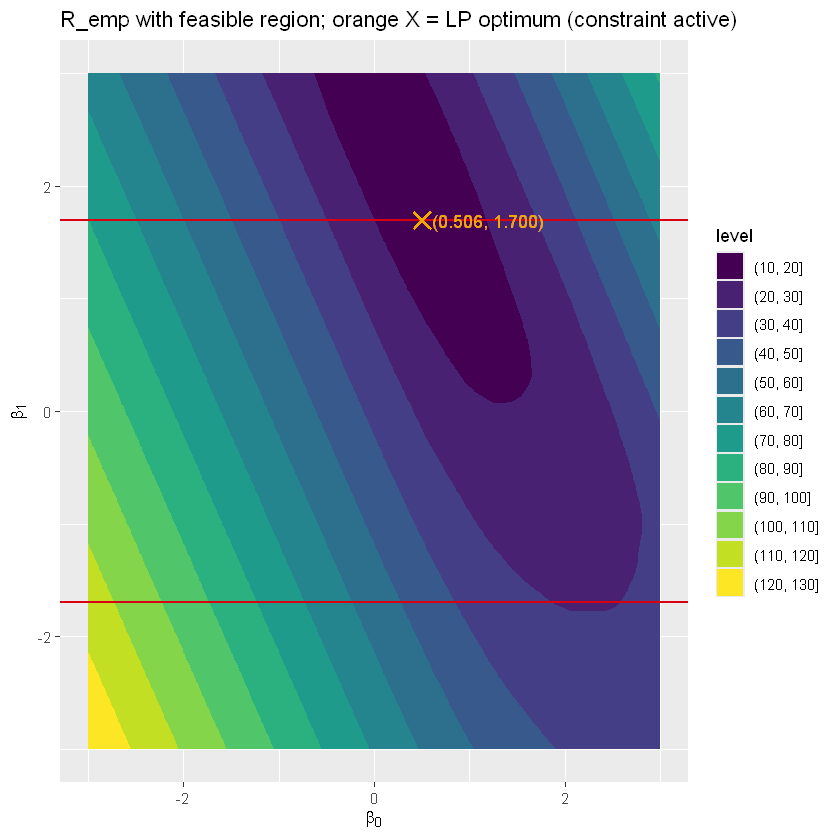

In [3]:
#| label: solution_c_code
library(linprog)

# Build the standard form (a):
#   z = (beta0+, beta0-, beta1+, beta1-, r1+,...,rn+, r1-,...,rn-)
#   c, A, b as in the prose above.
Amat <- c(0, 0, 1, 1, rep(0, 2 * n))                          # budget
# r+ - r- <= y - beta_0 - beta_1 x
Amat <- rbind(Amat, cbind(1, -1,  x, -x,  diag(n), -diag(n)))
Amat <- rbind(Amat, cbind(-1, 1, -x,  x, -diag(n),  diag(n))) # mirrored
bvec <- c(tval, y, -y)
cvec <- c(0, 0, 0, 0, rep(tau, n), rep(1 - tau, n))   # positive c, minimize

res <- solveLP(cvec, bvec, Amat, maximum = FALSE, lpSolve = TRUE)

beta0 <- res$solution[1] - res$solution[2]
beta1 <- res$solution[3] - res$solution[4]
constraint_active <- abs(abs(beta1) - tval) < 1e-6

cat(sprintf("beta_hat = (%+.4f, %+.4f), R_emp* = %.4f\n",
            beta0, beta1, remp(c(beta0, beta1))))
cat(sprintf("budget constraint |beta_1| <= %.2f is %s (|beta_1*| = %.4f)\n",
            tval, if (constraint_active) "ACTIVE" else "slack", abs(beta1)))

# Contour from (b), now with the LP optimum marked in parameter space.
remp_plot +
  annotate("point", x = beta0, y = beta1, color = "#F2A800",
           size = 3.5, shape = 4, stroke = 1.5) +
  annotate("text", x = beta0, y = beta1,
           label = sprintf("  (%.3f, %.3f)", beta0, beta1),
           hjust = 0, color = "#F2A800") +
  ggtitle(sprintf("R_emp with feasible region; orange X = LP optimum (%s)",
                  if (constraint_active) "constraint active" else "interior"))

INSERT_solution_c_text

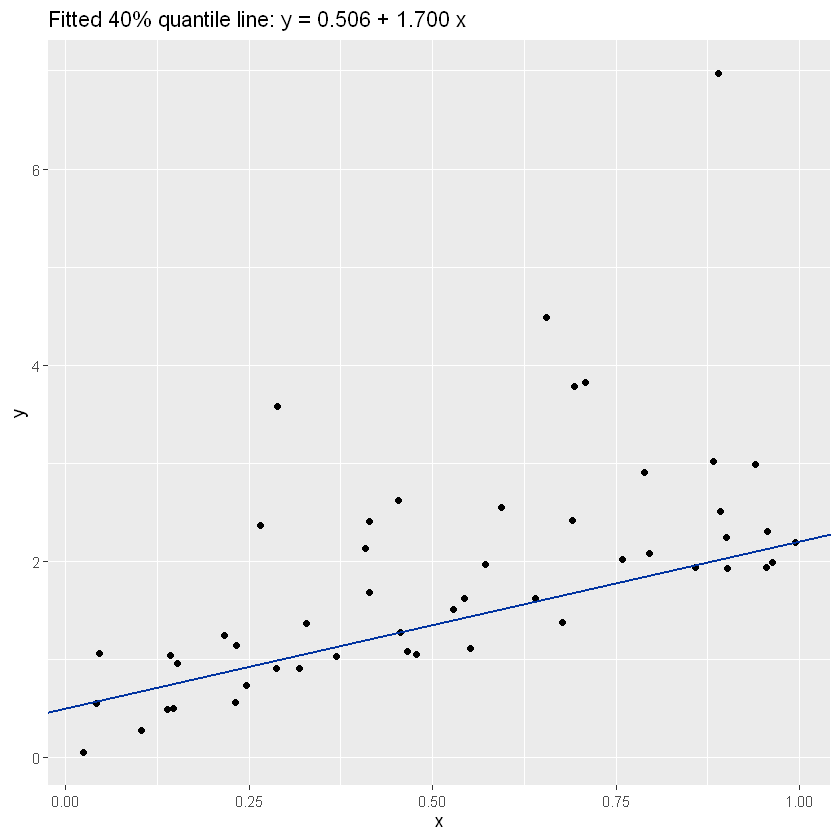

In [4]:
#| label: fitted_line_plot
ggplot(data.frame(x = x, y = y), aes(x, y)) +
  geom_point() +
  geom_abline(intercept = beta0, slope = beta1,
              color = "#0033A0", linewidth = 0.7) +
  ggtitle(sprintf("Fitted 40%% quantile line: y = %.3f + %.3f x", beta0, beta1))

INSERT_problem_d

**Solution.**

INSERT_solution_d_text